In [1]:
# Regresión Lineal por Inspección
# STP
# 20/02/24

import numpy as np # Library for mathematical arrays operations
import pandas as pd # Library for manipulation data and analysis
import matplotlib.pyplot as plt # Library for plotting
%pip install ucimlrepo # Install UCI Machine Learning repository

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo # Call the datasets that exists in UCI

# fetch dataset with ID = 53 is Iris dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
x = iris.data.features
y = iris.data.targets

print(type(x))
print(type(y))

x

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Los datos que muestran una correlación lineal son los de *ancho de pétalo* con *longitud de pétalo*.

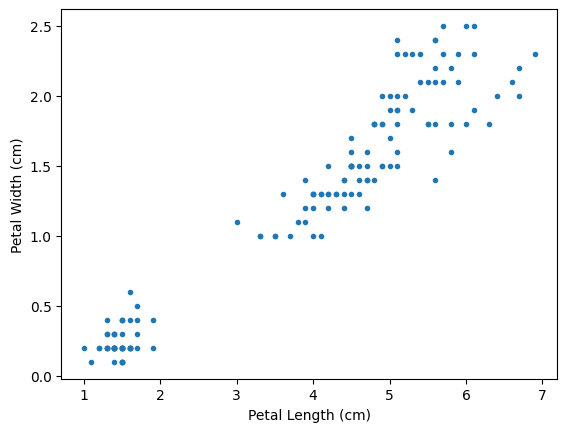

In [3]:
plt.plot(x["petal length"],x["petal width"],linestyle="none",marker=".",linewidth=0.5)
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.show()

/tmp/ipykernel_20701/3086846117.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x[column] = length
/tmp/ipykernel_20701/3086846117.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x[column] = length
/tmp/ipykernel_20701/3086846117.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x[column

Text(0.5, 0, 'Ancho del Pétalo (cm)')

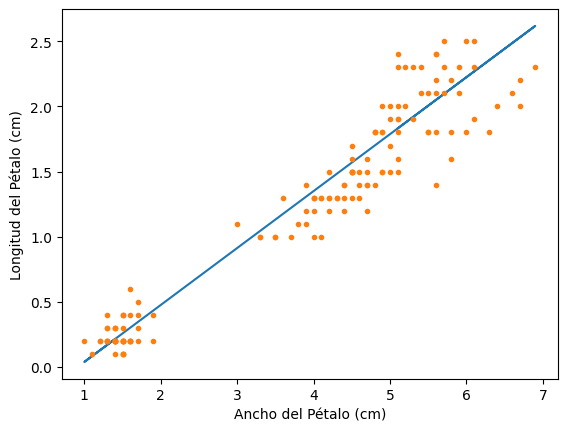

In [4]:
# m is an empty list
m = []
vlrm = 0.25

for i in range (0, 150, 1): #for best fitting, the values must be between 100-150 (?)
  vlrm = vlrm + 0.00125
  m.append(vlrm) # adding elements to m with vlrm in a loop

# E another empty list
E = []
error = 0

for pendiente in m:
    length = pendiente * x["petal width"] - 0.4
    column = f'length_{pendiente}'  # column with m
    x[column] = length
    # cost function for calculate the error value
    error = sum(((x['petal width'] - x[column])**2))/150
    E.append(error)

array = pd.Series(E)
minimum = array.idxmin()
m = pd.Series(m) #

fit =  m[minimum] * x["petal length"] - 0.4

plt.plot(x["petal length"],fit) # plotted regression
plt.plot(x["petal length"],x["petal width"],linestyle = "none", marker=".", linewidth = 0.5)
plt.ylabel ("Longitud del Pétalo (cm)")
plt.xlabel ("Ancho del Pétalo (cm)")